In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:

from google.colab import files

uploaded = files.upload()


Saving archive (8).zip to archive (8).zip


In [ ]:
import zipfile

zip_file = "archive (8).zip"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall("dataset")

In [ ]:
import os

print(os.listdir("dataset"))

['facemask-dataset', 'face_detector']


In [ ]:
import os

print(os.listdir("dataset/facemask-dataset"))

['dataset']


In [ ]:
import os

print(os.listdir("dataset/facemask-dataset/dataset"))

['without_mask', 'with_mask']


In [ ]:

input_folder = "dataset/facemask-dataset/dataset"

In [ ]:
!pip install -q split-folders

In [ ]:
import splitfolders

splitfolders.ratio(
    input_folder,
    output="output_dataset",
    seed=42,
    ratio=(0.7, 0.2, 0.1)
)

Copying files: 3833 files [00:02, 1851.57 files/s]


In [ ]:
import tensorflow as tf

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_data = tf.keras.utils.image_dataset_from_directory(
    "output_dataset/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=42
)

val_data = tf.keras.utils.image_dataset_from_directory(
    "output_dataset/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

test_data = tf.keras.utils.image_dataset_from_directory(
    "output_dataset/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

Found 2682 files belonging to 2 classes.
Found 766 files belonging to 2 classes.
Found 385 files belonging to 2 classes.


In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_data = train_data.map(
    lambda x, y: (normalization_layer(x), y)
)

val_data = val_data.map(
    lambda x, y: (normalization_layer(x), y)
)

test_data = test_data.map(
    lambda x, y: (normalization_layer(x), y)
)

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(128, 128, 3)),

    tf.keras.layers.Dense(256, activation="relu"),

    tf.keras.layers.Dense(128, activation="relu"),

    tf.keras.layers.Dense(64, activation="relu"),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,583,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,624,385 (48.16 MB)

 Trainable params: 12,624,385 (48.16 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 26s 307ms/step - accuracy: 0.7819 - loss: 0.6605 - val_accuracy: 0.9047 - val_loss: 0.2258
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 24s 283ms/step - accuracy: 0.8844 - loss: 0.3380 - val_accuracy: 0.9230 - val_loss: 0.2050
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 22s 259ms/step - accuracy: 0.8740 - loss: 0.3458 - val_accuracy: 0.7611 - val_loss: 0.7125
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 22s 255ms/step - accuracy: 0.8788 - loss: 0.3311 - val_accuracy: 0.9308 - val_loss: 0.1951
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 22s 267ms/step - accuracy: 0.8967 - loss: 0.2991 - val_accuracy: 0.9386 - val_loss: 0.1709
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 19s 224ms/step - accuracy: 0.9072 - loss: 0.2407 - val_accuracy: 0.9047 - val_loss: 0.2431
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 22s 265ms/step - accuracy: 0.9180 - loss: 0.2255 - val_accuracy: 0.9386 - val_loss: 0.1590
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 19s 224ms/step - accuracy: 0.9344 - loss: 0.1767 - val_accu

In [ ]:
test_loss, test_accuracy = model.evaluate(test_data)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - accuracy: 0.8909 - loss: 0.2971
Test Loss: 0.29706376791000366
Test Accuracy: 0.8909090757369995
Test Accuracy: 89.09%


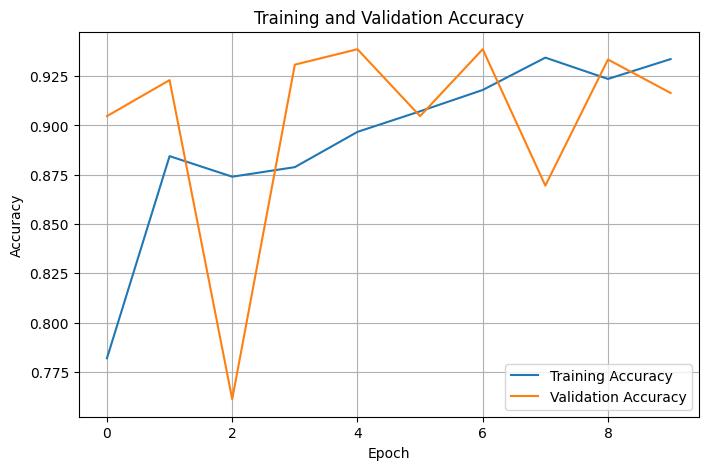

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

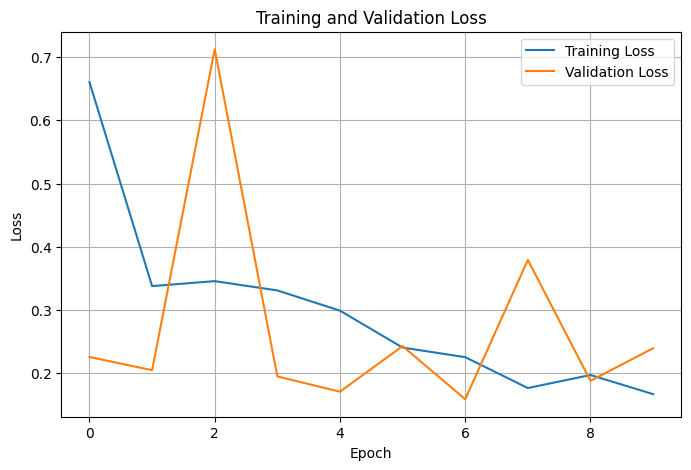

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

In [ ]:
model.save("face_mask_ann_model.keras")

print("Model saved successfully!")

Model saved successfully!
